<a href="https://colab.research.google.com/github/vidyouth/CardioAI/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



In [ ]:
url = "https://raw.githubusercontent.com/krishnakanth-G/Analyzing_Heart_Disease_Dataset/main/heart.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df



Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:

if "target" not in df.columns and "num" in df.columns:
    df.rename(columns={"num":"target"}, inplace=True)

df["target"] = (df["target"] > 0).astype(int)

# Check missing
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (242, 13) Test shape: (61, 13)


In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_log, digits=3))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf, digits=3))


Logistic Regression:
              precision    recall  f1-score   support

           0      0.864     0.679     0.760        28
           1      0.769     0.909     0.833        33

    accuracy                          0.803        61
   macro avg      0.816     0.794     0.797        61
weighted avg      0.813     0.803     0.800        61

Random Forest:
              precision    recall  f1-score   support

           0      0.947     0.643     0.766        28
           1      0.762     0.970     0.853        33

    accuracy                          0.820        61
   macro avg      0.855     0.806     0.810        61
weighted avg      0.847     0.820     0.813        61



In [ ]:
from sklearn.metrics import classification_report

# Logistic Regression
print("=== Logistic Regression ===")
print("Train report:\n", classification_report(y_train, log_reg.predict(X_train), digits=3))
print("Test report:\n", classification_report(y_test, log_reg.predict(X_test), digits=3))

# Random Forest
print("\n=== Random Forest ===")
print("Train report:\n", classification_report(y_train, rf.predict(X_train), digits=3))
print("Test report:\n", classification_report(y_test, rf.predict(X_test), digits=3))


=== Logistic Regression ===
Train report:
               precision    recall  f1-score   support

           0      0.867     0.773     0.817       110
           1      0.826     0.902     0.862       132

    accuracy                          0.843       242
   macro avg      0.847     0.837     0.840       242
weighted avg      0.845     0.843     0.842       242

Test report:
               precision    recall  f1-score   support

           0      0.864     0.679     0.760        28
           1      0.769     0.909     0.833        33

    accuracy                          0.803        61
   macro avg      0.816     0.794     0.797        61
weighted avg      0.813     0.803     0.800        61


=== Random Forest ===
Train report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000       110
           1      1.000     1.000     1.000       132

    accuracy                          1.000       242
   macro avg      1.000     1.000

In [ ]:
# Print parameter sets you trained with
print("Logistic Regression parameters:")
print(log_reg.get_params())
print("\nRandom Forest parameters:")
print(rf.get_params())



Logistic Regression parameters:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Random Forest parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np
from scipy.stats import randint as sp_randint

param_dist = {
    "n_estimators": [100,200,400],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": sp_randint(2, 11),
    "min_samples_leaf": sp_randint(1, 6),
    "max_features": ["sqrt", "log2", 0.6, 0.8],
    "class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,              # try 30 combinations (adjust if you have more time)
    scoring='f1',           # optimize F1 (balance precision & recall)
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

rs.fit(X_train, y_train)

print("Best RF params:", rs.best_params_)
best_rf = rs.best_estimator_

# Evaluate best model on test set
from sklearn.metrics import classification_report
y_pred_best = best_rf.predict(X_test)
print("\nBest RF test report:\n", classification_report(y_test, y_pred_best, digits=3))



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best RF test report:
               precision    recall  f1-score   support

           0      0.950     0.679     0.792        28
           1      0.780     0.970     0.865        33

    accuracy                          0.836        61
   macro avg      0.865     0.824     0.828        61
weighted avg      0.858     0.836     0.831        61



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],   # 'l1' needs solver change; keep l2 for simplicity
    "solver": ["liblinear", "lbfgs"]
}

gs = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, scoring='f1', cv=cv, n_jobs=-1)
gs.fit(X_train, y_train)
print("Best LogReg params:", gs.best_params_)
best_log = gs.best_estimator_
print("\nBest LogReg test report:\n", classification_report(y_test, best_log.predict(X_test), digits=3))



Best LogReg params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}

Best LogReg test report:
               precision    recall  f1-score   support

           0      0.947     0.643     0.766        28
           1      0.762     0.970     0.853        33

    accuracy                          0.820        61
   macro avg      0.855     0.806     0.810        61
weighted avg      0.847     0.820     0.813        61



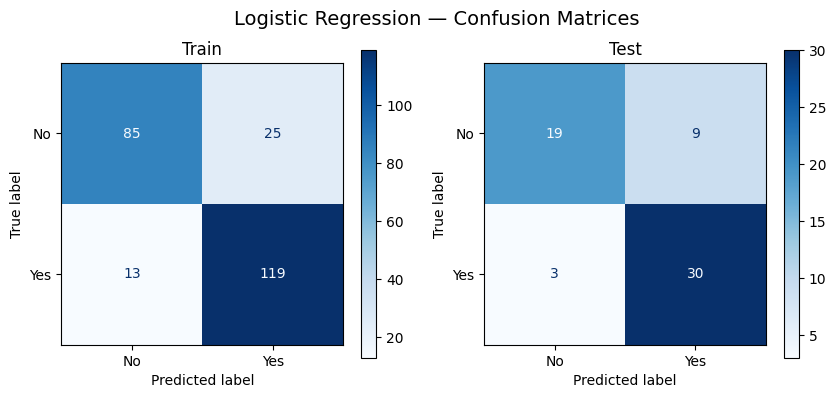

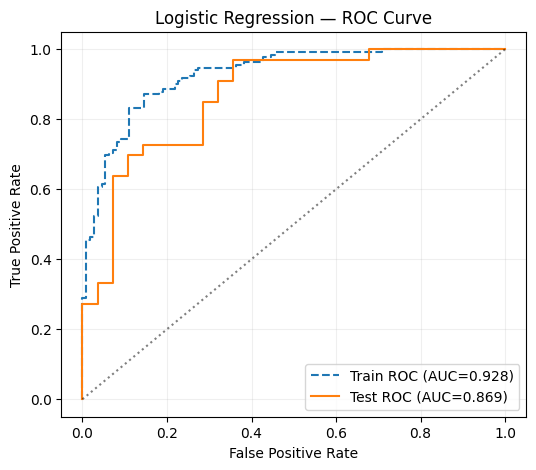

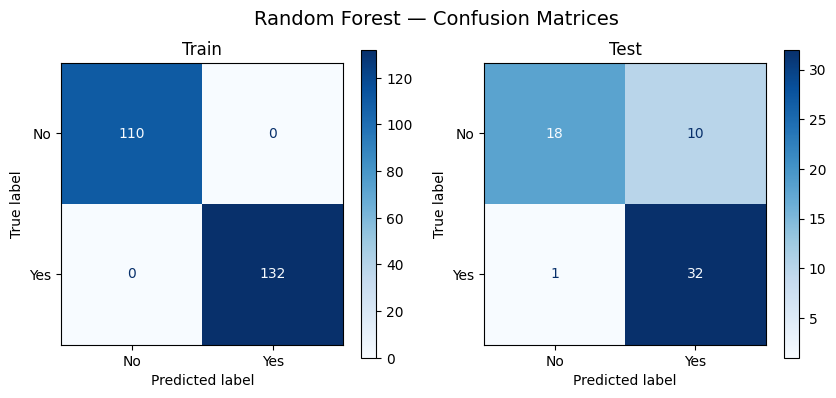

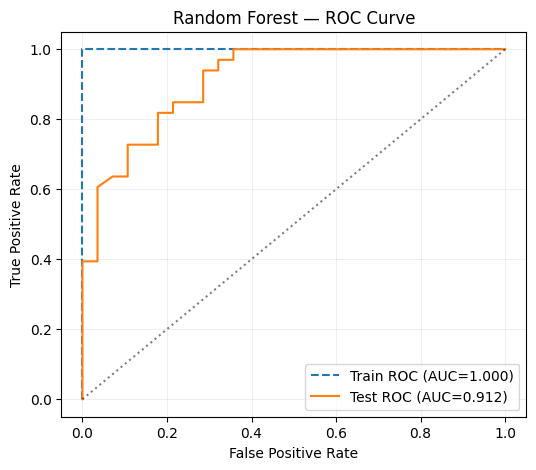

In [ ]:
# cell: plots for confusion matrices and ROC curves
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf
}

plt.rcParams.update({"figure.max_open_warning": 0})

for name, model in models.items():
    # --- predictions & probs ---
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    # some models have predict_proba, if not use decision_function
    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:,1]
        y_test_proba  = model.predict_proba(X_test)[:,1]
    else:
        # fallback
        y_train_proba = model.decision_function(X_train)
        y_test_proba  = model.decision_function(X_test)

    # --- Plot confusion matrices side-by-side ---
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    fig.suptitle(f"{name} — Confusion Matrices", fontsize=14)
    ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0], cmap="Blues", display_labels=["No","Yes"])
    axes[0].set_title("Train")
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=axes[1], cmap="Blues", display_labels=["No","Yes"])
    axes[1].set_title("Test")
    plt.show()

    # --- ROC curves (train & test) ---
    fpr_t, tpr_t, _ = roc_curve(y_train, y_train_proba)
    fpr, tpr, _     = roc_curve(y_test, y_test_proba)
    auc_train = auc(fpr_t, tpr_t)
    auc_test  = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr_t, tpr_t, label=f"Train ROC (AUC={auc_train:.3f})", linestyle="--")
    plt.plot(fpr, tpr, label=f"Test ROC (AUC={auc_test:.3f})", linestyle="-")
    plt.plot([0,1],[0,1],"k:", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} — ROC Curve")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


=== XGBoost Classification Reports ===

Train report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000       110
           1      1.000     1.000     1.000       132

    accuracy                          1.000       242
   macro avg      1.000     1.000     1.000       242
weighted avg      1.000     1.000     1.000       242

Test report:
               precision    recall  f1-score   support

           0      0.857     0.643     0.735        28
           1      0.750     0.909     0.822        33

    accuracy                          0.787        61
   macro avg      0.804     0.776     0.778        61
weighted avg      0.799     0.787     0.782        61



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:44:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


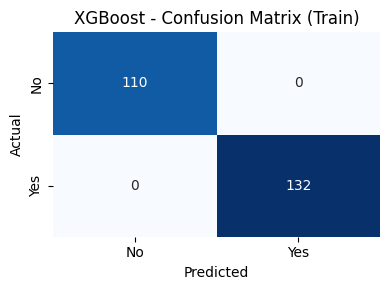

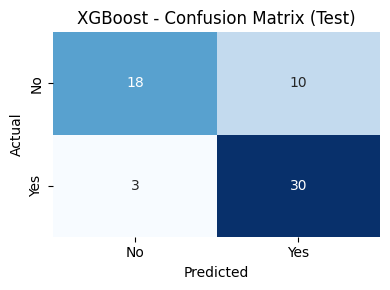

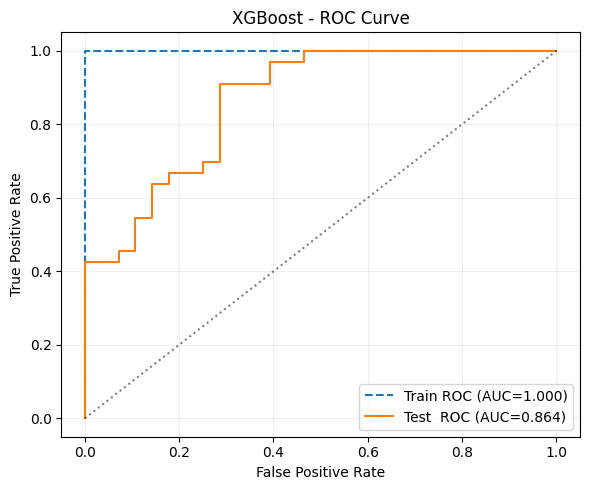

Saved model to cardio_xgb.joblib and scaler to cardio_scaler.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# === Cell: Train XGBoost, plot matrices + ROC, save model ===
# Run this after X_train, X_test, y_train, y_test, and scaler exist

# 0) Install xgboost if needed (Colab)
!pip install xgboost --quiet

# 1) Imports
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 2) Train XGBoost (good default params)
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

# 3) Reports (train & test)
print("=== XGBoost Classification Reports ===\n")
print("Train report:\n", classification_report(y_train, xgb.predict(X_train), digits=3))
print("Test report:\n", classification_report(y_test, xgb.predict(X_test), digits=3))

# 4) Confusion matrices (heatmaps)
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["No","Yes"], yticklabels=["No","Yes"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_train, xgb.predict(X_train), "XGBoost - Confusion Matrix (Train)")
plot_confusion(y_test,  xgb.predict(X_test),  "XGBoost - Confusion Matrix (Test)")

# 5) ROC curves + AUC (train & test)
# Use predict_proba for probabilities of positive class
y_train_proba = xgb.predict_proba(X_train)[:,1]
y_test_proba  = xgb.predict_proba(X_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_proba)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_proba)
auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)

plt.figure(figsize=(6,5))
plt.plot(fpr_tr, tpr_tr, linestyle='--', label=f"Train ROC (AUC={auc_tr:.3f})")
plt.plot(fpr_te, tpr_te, linestyle='-',  label=f"Test  ROC (AUC={auc_te:.3f})")
plt.plot([0,1],[0,1], 'k:', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC Curve")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 6) Save the model + scaler (joblib) so you can demo later
model_name = "cardio_xgb.joblib"
scaler_name = "cardio_scaler.joblib"
joblib.dump(xgb, model_name)
joblib.dump(scaler, scaler_name)   # 'scaler' is your StandardScaler object used earlier
print(f"Saved model to {model_name} and scaler to {scaler_name}")

# 7) Provide download links in Colab (optional)
from google.colab import files
files.download(model_name)
files.download(scaler_name)


In [ ]:
# Install xgboost if needed
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

# Base model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Parameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 3, 5]
}

# Stratified K-Fold for balanced validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search
rs_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=40,              # tries 40 random combos
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=42
)

# Fit on training data
rs_xgb.fit(X_train, y_train)

# Best model
best_xgb = rs_xgb.best_estimator_
print("Best XGBoost params:", rs_xgb.best_params_)

# Evaluate
print("\n=== Best XGBoost Classification Report ===")
print("Train report:\n", classification_report(y_train, best_xgb.predict(X_train), digits=3))
print("Test report:\n", classification_report(y_test, best_xgb.predict(X_test), digits=3))



Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGBoost params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}

=== Best XGBoost Classification Report ===
Train report:
               precision    recall  f1-score   support

           0      0.928     0.818     0.870       110
           1      0.862     0.947     0.903       132

    accuracy                          0.888       242
   macro avg      0.895     0.883     0.886       242
weighted avg      0.892     0.888     0.888       242

Test report:
               precision    recall  f1-score   support

           0      0.944     0.607     0.739        28
           1      0.744     0.970     0.842        33

    accuracy                          0.803        61
   macro avg      0.844     0.788     0.791        61
weighted avg      0.836     0.803     0.795        61



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:45:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


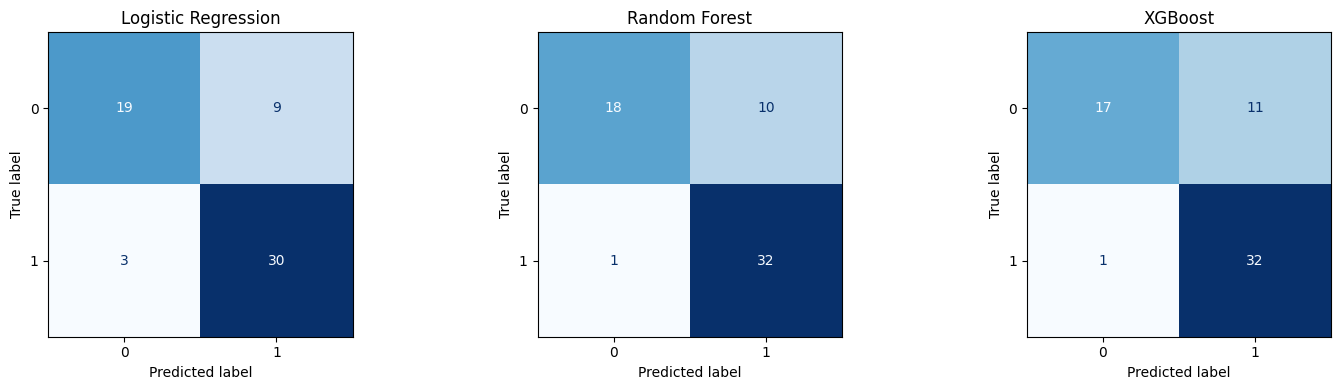

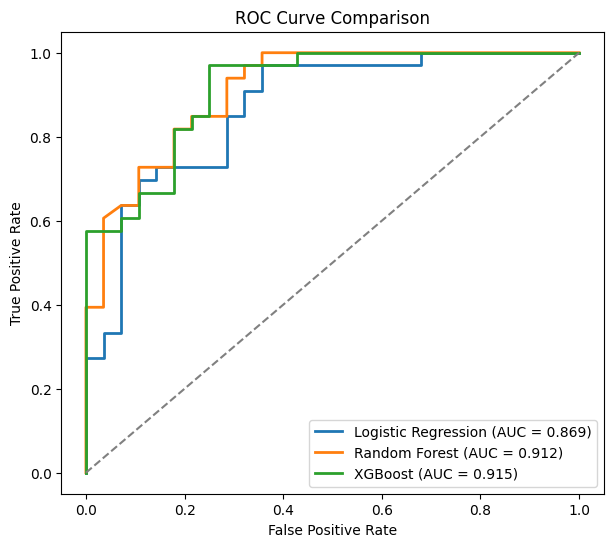

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import numpy as np

# Store all models in a dictionary for easy looping
models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": best_xgb
}

plt.figure(figsize=(15, 4))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.subplot(1, 3, i+1)
    disp.plot(cmap="Blues", ax=plt.gca(), colorbar=False)
    plt.title(name)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

